# NYC Taxi Trip Duration — Walkthrough

A short narrative tour of the data and the three trained models. This is the
notebook that gets screen-shared during teaching: load the sample, look at the
duration distribution, look at duration by hour of day, then compare all
three models' predictions against actuals.


In [1]:
import sys
sys.path.insert(0, "..")

import matplotlib.pyplot as plt
import mlflow
import pandas as pd

from src.features import build_features
from src.train import clean, temporal_split

plt.rcParams["figure.figsize"] = (9, 4.5)


## Load the sample data and clean it

In [2]:
df = pd.read_parquet("../data/processed/sample.parquet")
df = clean(df)
print(f"{len(df):,} trips after cleaning")
df[["trip_distance", "duration_min", "passenger_count"]].describe()


194,791 trips after cleaning


,trip_distance,duration_min,passenger_count
count,194791.000000,194791.000000,190691.000000
mean,3.318483,14.186844,1.363274
std,4.152135,9.914243,0.894615
min,0.010000,1.000000,0.000000
25%,1.100000,7.216667,1.000000
50%,1.800000,11.533333,1.000000
75%,3.340000,18.166667,1.000000
max,52.650000,60.000000,6.000000


## Duration distribution

Most trips are short — the median is well under 15 minutes — with a long
right tail of longer cross-borough trips.


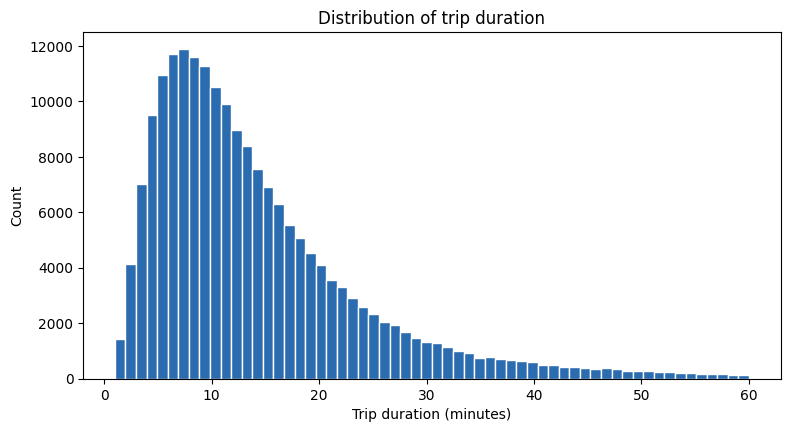

Median duration: 11.5 min
Mean duration:   14.2 min


In [3]:
fig, ax = plt.subplots()
ax.hist(df["duration_min"], bins=60, color="#2b6cb0", edgecolor="white")
ax.set_xlabel("Trip duration (minutes)")
ax.set_ylabel("Count")
ax.set_title("Distribution of trip duration")
plt.show()

print(f"Median duration: {df['duration_min'].median():.1f} min")
print(f"Mean duration:   {df['duration_min'].mean():.1f} min")


## Duration by hour of day

Average trip duration rises through the morning, peaks around rush hour, and
dips overnight — traffic congestion, not distance, is doing most of that
work (see the README's "Feature engineering" section for why).


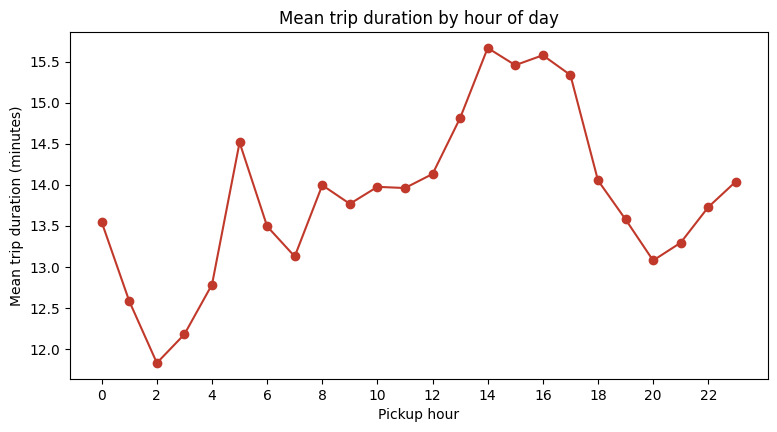

In [4]:
hourly = df.copy()
hourly["pickup_hour"] = pd.to_datetime(hourly["tpep_pickup_datetime"]).dt.hour
by_hour = hourly.groupby("pickup_hour")["duration_min"].mean()

fig, ax = plt.subplots()
ax.plot(by_hour.index, by_hour.values, marker="o", color="#c0392b")
ax.set_xlabel("Pickup hour")
ax.set_ylabel("Mean trip duration (minutes)")
ax.set_title("Mean trip duration by hour of day")
ax.set_xticks(range(0, 24, 2))
plt.show()


## Compare all three models: predictions vs actuals

Load each run's model straight from `mlruns/` (via `runs:/<run_id>/model`,
so the vectorizer travels with each model) and scatter predicted vs actual
duration on the same held-out validation split used during training.


In [5]:
mlflow.set_tracking_uri("file:../mlruns")

train_df, val_df = temporal_split(df)
X_val = build_features(val_df)
y_val = val_df["duration_min"].values

client = mlflow.MlflowClient()
experiment = client.get_experiment_by_name("nyc-taxi-duration")
runs = client.search_runs(experiment.experiment_id, order_by=["start_time ASC"])

models = {}
for run in runs:
    name = run.data.tags.get("mlflow.runName", run.info.run_id)
    models[name] = mlflow.sklearn.load_model(f"runs:/{run.info.run_id}/model")

list(models.keys())


['linear_regression', 'random_forest', 'xgboost']

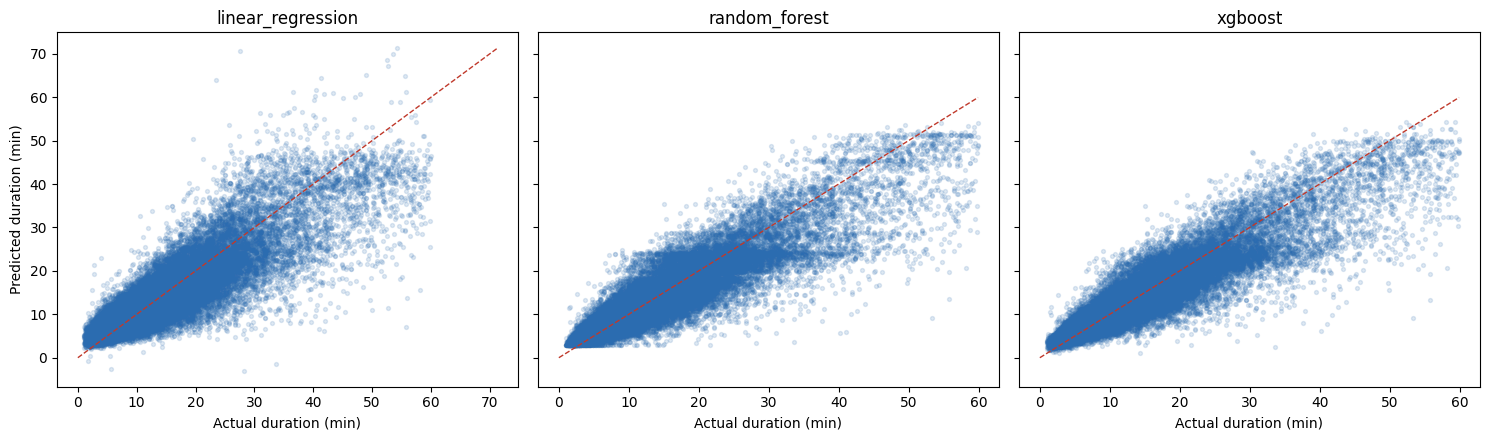

In [6]:
fig, axes = plt.subplots(1, len(models), figsize=(5 * len(models), 4.5), sharey=True)

for ax, (name, model) in zip(axes, models.items()):
    preds = model.predict(X_val)
    ax.scatter(y_val, preds, alpha=0.15, s=8, color="#2b6cb0")
    lims = [0, max(y_val.max(), preds.max())]
    ax.plot(lims, lims, color="#c0392b", linewidth=1, linestyle="--")
    ax.set_xlabel("Actual duration (min)")
    ax.set_title(name)

axes[0].set_ylabel("Predicted duration (min)")
plt.tight_layout()
plt.show()


Linear regression's predictions cluster in a narrower band (it can only fit
a global slope), while random forest and XGBoost track the diagonal more
closely — especially for the bulk of short-to-medium trips where most of the
data lives. See the README's results table for the exact RMSE/MAE/R² numbers.
